# How accurate is `orthant_cdf` on choice shares?

This is a one-time accuracy test. Later comparisons of `orthant_cdf` with RFC
cite its table and do not recompute SciPy references. Each choice share at
$K = 5$ is a 4-dimensional orthant probability of the utility differences (see
`rfc_vs_exact.ipynb`, section 1). The model, design and part-worths are the
same as there.

**Scenarios**

- 300 stratified sets: 100 with an exact twin, 100 with a near-twin
  (differing only on A4 and A5), and 100 with no similar products.
- A **sweep** of 50 twin sets, each with $\sigma_P$ chosen so that the largest
  correlation of its difference covariances hits a target between 0.55 and
  0.999. As $\sigma_P \to \infty$ that correlation tends to 0.5, so 0.5 itself
  cannot be reached.

**Reference**: SciPy `multivariate_normal.cdf` with `abseps = releps = 1e-7`
and `maxpts = 4·10⁷`, computed once and cached in
`orthant_accuracy_ref.npz`. A rerun reuses the cache and only recomputes
`orthant_cdf`.

**Aggregation** uses 1,000 respondents ($\beta_n = \beta + 0.4 z_n$) on 2
scenarios per group. Its reference uses `abseps = releps = 1e-6`, 8 times
faster. That is still about 1,000 times smaller than the errors being
measured, and it is cached too.

Error means `orthant_cdf` − SciPy, in share units.

In [1]:
import os, time
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
import rfc
pd.set_option("display.precision", 5)
CACHE = "orthant_accuracy_ref.npz"
rng = np.random.default_rng(31)

# 300 stratified scenarios
X_s, kind_s = rfc.make_sets(300, rng)
V, S = rfc.utility_moments(X_s)
up_s, cov_s = rfc.orthant_problems(V, S)                       # (1500, 4), (1500, 4, 4)
group_s = np.repeat(kind_s, 5)
scen_s = np.repeat(np.arange(300), 5)

# correlation sweep: twin sets, sigma_P solved for each target max correlation
targets = 1 - np.geomspace(0.45, 0.001, 50)
X_tw, _ = rfc.make_sets(200, rng, kinds=("twin",))
sweep_X, sweep_sp, sweep_target = [], [], []
for x in X_tw:
    if len(sweep_X) == len(targets):
        break
    sp = rfc.sigma_p_for_corr(x, targets[len(sweep_X)])
    if sp is not None:
        sweep_X.append(x); sweep_sp.append(sp); sweep_target.append(targets[len(sweep_X) - 1])
sweep_X, sweep_sp = np.array(sweep_X), np.array(sweep_sp)
up_w, cov_w = [], []
for x, sp in zip(sweep_X, sweep_sp):
    u, c = rfc.orthant_problems(*rfc.utility_moments(x[None], sigma_p=sp))
    up_w.append(u); cov_w.append(c)
up_w, cov_w = np.concatenate(up_w), np.concatenate(cov_w)     # (250, 4), (250, 4, 4)
scen_w = np.repeat(np.arange(len(sweep_X)), 5)

# aggregation: 1,000 respondents on 2 scenarios per group
N_RESP = 1000
agg_idx = np.concatenate([np.where(kind_s == g)[0][:2] for g in ("twin", "near", "plain")])
B = rfc.respondent_betas(N_RESP, rng, spread=0.4)
up_a = np.array([[u for u, _ in rfc.shared_problems(X_s[i], B)] for i in agg_idx])    # (6, 5, 1000, 4)
cov_a = np.array([[c for _, c in rfc.shared_problems(X_s[i], B)] for i in agg_idx])   # (6, 5, 4, 4)
print(f"{len(up_s)} stratified orthants, {len(up_w)} sweep orthants (sigma_P {sweep_sp.min():.3f} to {sweep_sp.max():.2f}), "
      f"{up_a[..., 0].size} aggregation orthants")

1500 stratified orthants, 250 sweep orthants (sigma_P 0.036 to 2.57), 30000 aggregation orthants


In [2]:
def load_or_compute():
    if os.path.exists(CACHE):
        z = np.load(CACHE)
        if all(np.array_equal(z[k], v) for k, v in
               (("up_s", up_s), ("cov_s", cov_s), ("up_w", up_w), ("cov_w", cov_w), ("up_a", up_a), ("cov_a", cov_a))):
            print("reference loaded from", CACHE, f"(computed in {float(z['seconds']):.0f} s)")
            return z["ref_s"], z["ref_w"], z["ref_a"]
    t = time.perf_counter()
    ref_s = rfc.scipy_orthants(up_s, cov_s, tol=1e-7)
    ref_w = rfc.scipy_orthants(up_w, cov_w, tol=1e-7)
    flat_up = up_a.reshape(-1, 4)
    flat_cov = np.repeat(cov_a.reshape(-1, 4, 4), N_RESP, axis=0)
    ref_a = rfc.scipy_orthants(flat_up, flat_cov, tol=1e-6).reshape(up_a.shape[:3])
    seconds = time.perf_counter() - t
    np.savez(CACHE, up_s=up_s, cov_s=cov_s, ref_s=ref_s, up_w=up_w, cov_w=cov_w, ref_w=ref_w,
             up_a=up_a, cov_a=cov_a, ref_a=ref_a, seconds=seconds)
    print(f"reference computed in {seconds:.0f} s and cached")
    return ref_s, ref_w, ref_a

ref_s, ref_w, ref_a = load_or_compute()
print("reference self-check: stratified shares sum to 1 within", f"{np.abs(ref_s.reshape(300, 5).sum(1) - 1).max():.1e}")

reference loaded from orthant_accuracy_ref.npz (computed in 451 s)
reference self-check: stratified shares sum to 1 within 9.3e-07


In [3]:
rfc.orthant_cdf(up_s[:5], cov_s[:5])                                 # wake the service
oc_s = rfc.orthant_cdf(up_s, cov_s)
oc_w = rfc.orthant_cdf(up_w, cov_w)
oc_a = np.array([[rfc.orthant_cdf(up_a[i, k], cov_a[i, k]) for k in range(5)] for i in range(len(agg_idx))])
err_s, err_w = oc_s - ref_s, oc_w - ref_w
corr_s, corr_w = rfc.max_diff_corr(cov_s), rfc.max_diff_corr(cov_w)  # per orthant

## Error by scenario type

The bias test is clustered by scenario, because the 5 shares of one scenario
share their errors. It is a one-sample t-test on the per-scenario mean
signed error. "worst share at" gives the role of the share with the largest
error: a twin or near-twin member (alternatives 0 and 1) or another product.

In [4]:
def summarize(err, scen, ref, role=None):
    per_scen = pd.Series(err).groupby(scen).mean()
    t = stats.ttest_1samp(per_scen, 0.0)
    i = np.argmax(np.abs(err))
    return dict(n_shares=len(err), bias=err.mean(), sd=err.std(ddof=1), max_abs=np.abs(err).max(),
                median_abs=np.median(np.abs(err)), bias_p_value=t.pvalue,
                worst_share_ref_p=ref[i], worst_share_at=None if role is None else role[i])

role_s = np.where(np.tile(np.arange(5), 300) < 2, "pair member", "other")
rows = {}
for g in ("twin", "near", "plain"):
    m = group_s == g
    rows[g] = summarize(err_s[m], scen_s[m], ref_s[m], np.where(role_s[m] == "pair member", f"{g} member", "other") if g != "plain" else role_s[m].astype(object) * 0 + "any")
rows["all 300"] = summarize(err_s, scen_s, ref_s)
rows["sweep (50 twin sets)"] = summarize(err_w, scen_w, ref_w)
by_group = pd.DataFrame(rows).T
by_group

,n_shares,bias,sd,max_abs,median_abs,bias_p_value,worst_share_ref_p,worst_share_at
twin,500,-0.00134,0.00249,0.01132,0.00103,0.0,0.45272,other
near,500,-0.00135,0.00239,0.01904,0.0008,0.0,0.51678,other
plain,500,-0.00035,0.00136,0.00689,0.00051,0.00001,0.31516,any
all 300,1500.0,-0.00102,0.00219,0.01904,0.00076,0.0,0.51678,NaN
sweep (50 twin sets),250.0,-0.00197,0.00651,0.0444,0.00112,0.0004,0.1914,NaN


In [5]:
# twin and near groups split by share role: is the error on the pair members or on the others?
role_rows = {}
for g in ("twin", "near"):
    for r in ("pair member", "other"):
        m = (group_s == g) & (role_s == r)
        e = err_s[m]
        role_rows[f"{g}: {r}"] = dict(n=len(e), bias=e.mean(), sd=e.std(ddof=1), max_abs=np.abs(e).max(),
                                      bias_p_value=stats.ttest_1samp(pd.Series(e).groupby(scen_s[m]).mean(), 0).pvalue)
pd.DataFrame(role_rows).T

,n,bias,sd,max_abs,bias_p_value
twin: pair member,200.0,-0.00067,0.00200,0.01107,1.27532e-03
twin: other,300.0,-0.00179,0.00268,0.01132,5.73520e-17
near: pair member,200.0,-0.00056,0.00153,0.00687,3.51386e-04
near: other,300.0,-0.00188,0.00270,0.01904,7.21694e-19


In [6]:
# by size of the true share
pbins = [0, 0.05, 0.15, 0.3, 0.5, 1.0]
size_rows = {}
for lo, hi in zip(pbins[:-1], pbins[1:]):
    m = (ref_s >= lo) & (ref_s < hi)
    e = err_s[m]
    size_rows[f"[{lo}, {hi})"] = dict(n=m.sum(), bias=e.mean(), sd=e.std(ddof=1), max_abs=np.abs(e).max(),
                                     relative_bias=e.mean() / ref_s[m].mean(),
                                     bias_p_value=stats.ttest_1samp(pd.Series(e).groupby(scen_s[m]).mean(), 0).pvalue)
print("stratified 300, by true share"); display(pd.DataFrame(size_rows).T)
print(f"shares of a scenario sum to: mean {oc_s.reshape(300, 5).sum(1).mean():.5f}, "
      f"min {oc_s.reshape(300, 5).sum(1).min():.5f} (exact: 1)")

stratified 300, by true share


,n,bias,sd,max_abs,relative_bias,bias_p_value
"[0, 0.05)",544.0,-0.00031,0.00117,0.00655,-0.01826,4.31967e-07
"[0.05, 0.15)",306.0,-0.00043,0.00209,0.01027,-0.00473,5.03199e-05
"[0.15, 0.3)",240.0,-0.00148,0.00240,0.01140,-0.00671,3.49069e-10
"[0.3, 0.5)",246.0,-0.00221,0.00278,0.01132,-0.00571,3.04187e-19
"[0.5, 1.0)",164.0,-0.00195,0.00242,0.01904,-0.00280,1.31735e-19


shares of a scenario sum to: mean 0.99492, min 0.96881 (exact: 1)


## Error by correlation of the difference covariance

The bins use each orthant's own largest correlation. The sweep is reported
separately because it also changes $\sigma_P$.

In [7]:
bins = [0.5, 0.8, 0.9, 0.95, 0.99, 0.999, 1.0 + 1e-12]
def by_corr(err, corr, scen):
    out = {}
    for lo, hi in zip(bins[:-1], bins[1:]):
        m = (corr >= lo) & (corr < hi)
        if m.sum() < 5:
            continue
        per = pd.Series(err[m]).groupby(scen[m]).mean()
        out[f"[{lo}, {min(hi, 1):.3g})"] = dict(n=m.sum(), bias=err[m].mean(), sd=err[m].std(ddof=1),
                                               max_abs=np.abs(err[m]).max(),
                                               bias_p_value=stats.ttest_1samp(per, 0).pvalue if len(per) > 2 else np.nan)
    return pd.DataFrame(out).T
print("stratified 300"); display(by_corr(err_s, corr_s, scen_s))
print("sweep");          display(by_corr(err_w, corr_w, scen_w))

stratified 300


,n,bias,sd,max_abs,bias_p_value
"[0.5, 0.8)",1010.0,-0.00065,0.00178,0.01132,1.79812e-17
"[0.8, 0.9)",420.0,-0.00200,0.00281,0.01904,4.37762e-25


sweep


,n,bias,sd,max_abs,bias_p_value
"[0.5, 0.8)",86.0,-0.00054,0.00330,0.01290,0.41663
"[0.8, 0.9)",31.0,-0.00206,0.00492,0.01982,0.08686
"[0.9, 0.95)",22.0,-0.00608,0.00896,0.03118,0.01002
"[0.95, 0.99)",38.0,-0.00720,0.00907,0.04440,0.00002
"[0.99, 0.999)",51.0,0.00068,0.00658,0.03013,0.62433


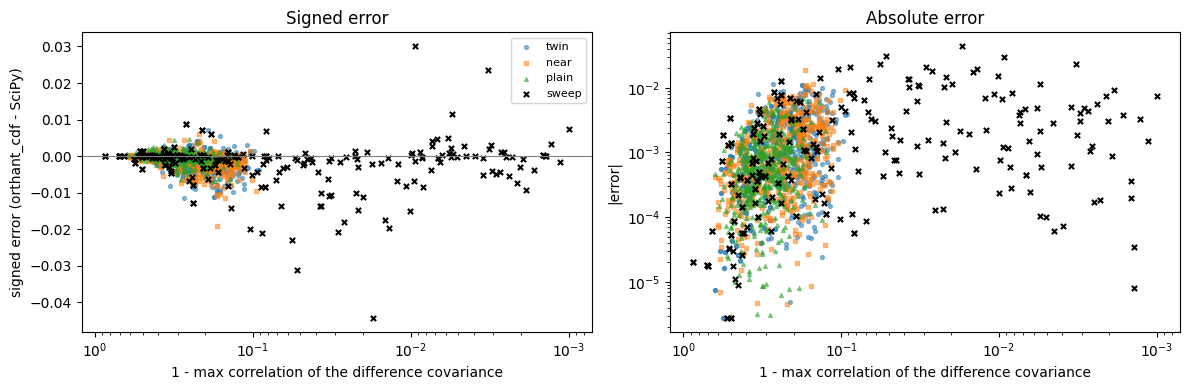

In [8]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
for g, mk in (("twin", "o"), ("near", "s"), ("plain", "^")):
    m = group_s == g
    ax[0].scatter(1 - corr_s[m], err_s[m], s=8, marker=mk, alpha=.5, label=g)
    ax[1].scatter(1 - corr_s[m], np.abs(err_s[m]) + 1e-8, s=8, marker=mk, alpha=.5, label=g)
ax[0].scatter(1 - corr_w, err_w, s=14, c="k", marker="x", label="sweep")
ax[1].scatter(1 - corr_w, np.abs(err_w) + 1e-8, s=14, c="k", marker="x", label="sweep")
for a in ax:
    a.set_xscale("log"); a.invert_xaxis(); a.set_xlabel("1 - max correlation of the difference covariance")
ax[0].axhline(0, c="gray", lw=.8); ax[0].set(ylabel="signed error (orthant_cdf - SciPy)", title="Signed error")
ax[1].set_yscale("log"); ax[1].set(ylabel="|error|", title="Absolute error")
ax[0].legend(fontsize=8); plt.tight_layout(); plt.show()

## Does the error average out across respondents?

For each of the 6 scenarios and 5 products, the market-share error is the
mean over 1,000 respondents of the per-respondent error. If the per-respondent
errors were independent noise, it would be about $\text{sd}/\sqrt{1000}$. If
they share a bias, it stays near the mean signed error.

In [9]:
e_ind = oc_a - ref_a                                  # (6, 5, 1000)
agg_rows = []
for i, s in enumerate(agg_idx):
    for k in range(5):
        e = e_ind[i, k]
        agg_rows.append(dict(scenario=int(s), group=kind_s[s], product=k, market_share=ref_a[i, k].mean(),
                             individual_mean_abs=np.abs(e).mean(), individual_sd=e.std(ddof=1),
                             aggregate_error=e.mean(), noise_only_expect=e.std(ddof=1) / np.sqrt(N_RESP)))
agg = pd.DataFrame(agg_rows)
agg["aggregate / noise-only"] = agg.aggregate_error.abs() / agg.noise_only_expect
display(agg)
print(f"mean |individual error| {agg.individual_mean_abs.mean():.5f}; mean |aggregate error| "
      f"{agg.aggregate_error.abs().mean():.5f}; max |aggregate error| {agg.aggregate_error.abs().max():.5f}")

,scenario,group,product,market_share,individual_mean_abs,individual_sd,aggregate_error,noise_only_expect,aggregate / noise-only
0,1,twin,0,0.22979,0.00162,0.00196,-1.87895e-04,6.18658e-05,3.03714
1,1,twin,1,0.22979,0.00162,0.00196,-1.87919e-04,6.18662e-05,3.03751
2,1,twin,2,0.01147,0.00059,0.00085,-5.93155e-04,2.67638e-05,22.16260
3,1,twin,3,0.51469,0.00693,0.00185,-6.93465e-03,5.83824e-05,118.77997
4,1,twin,4,0.01426,0.00062,0.00116,-5.18849e-04,3.66561e-05,14.15450
5,4,twin,0,0.19680,0.00163,0.00182,-4.45911e-04,5.74148e-05,7.76648
6,4,twin,1,0.19680,0.00163,0.00182,-4.45943e-04,5.74157e-05,7.76692
7,4,twin,2,0.01209,0.00040,0.00070,-3.11187e-04,2.21858e-05,14.02643
8,4,twin,3,0.33487,0.00544,0.00256,-5.44357e-03,8.09955e-05,67.20825
9,4,twin,4,0.25944,0.00619,0.00321,-6.18800e-03,1.01622e-04,60.89214


mean |individual error| 0.00177; mean |aggregate error| 0.00136; max |aggregate error| 0.00693


## Summary

In [10]:
summary = by_group[["n_shares", "bias", "sd", "max_abs", "bias_p_value"]].copy()
ag = agg.groupby("group").aggregate_error.agg(lambda x: x.abs().max())
summary["max |market-share error|, 1,000 resp."] = [ag.get(g, np.nan) for g in summary.index]
summary

,n_shares,bias,sd,max_abs,bias_p_value,"max |market-share error|, 1,000 resp."
twin,500,-0.00134,0.00249,0.01132,0.0,0.00693
near,500,-0.00135,0.00239,0.01904,0.0,0.00378
plain,500,-0.00035,0.00136,0.00689,0.00001,0.00305
all 300,1500.0,-0.00102,0.00219,0.01904,0.0,NaN
sweep (50 twin sets),250.0,-0.00197,0.00651,0.0444,0.0004,NaN


**Conclusion: the error is biased, so the regime below should be flagged.**

`orthant_cdf` underestimates choice shares. The bias is nonzero in every group
(clustered t-test p ≤ 1e-5):

- −0.0013 with an exact twin or a near-twin, and −0.0004 with no similar
  products.
- The 5 shares of a scenario sum to 0.995 on average, and as low as 0.969.
- The bias grows with share size: about −0.002 for shares above 0.3, against
  −0.0003 below 0.05.
- It grows with the largest correlation of the difference covariance. In the
  sweep it was −0.006 to −0.007 for correlations of 0.9–0.99, with errors up to
  0.044.

It does not average out. Across 1,000 respondents the market-share error
stayed at 0.0014 on average (0.0069 at worst, in a twin scenario). That is 3
to 120 times what independent noise would leave, and almost as large as the
per-respondent error of 0.0018.

The 0.018-size worst case is not in the twin group. Here the worst share
(0.019) was in a near-twin scenario, on a product that is *not* part of the
pair and has a true share of 0.52. Within twin and near-twin scenarios the pair
members' error is about a third of the other products' error.

**Flag:**

- Large shares (above about 0.15) in scenarios with a twin or near-twin.
- Any scenario whose difference covariance has a correlation of 0.9 or more.

Outside that regime the error is a small but systematic underestimate (about
−0.0004, at most 0.007). That is acceptable at a tolerance of about 0.01 but
not at 0.001. One possible correction is to renormalize each scenario's shares
to sum to 1; it is untested here.

**After renormalizing** (final section): shares rescaled to sum to 1 halve
both the market-share error (at most 0.0035 at 1,000 respondents) and the
largest share error in the stratified sets (0.009). A residual bias of about
0.001 remains: in scenarios with a twin or near-twin the pair members come out
too high and the other products too low, and this does not average out across
respondents. At max correlation ≥ 0.9 the error stays large (sd 0.0065,
max 0.034). Later sections use renormalized `orthant_cdf` shares, cite this
table, and flag max correlation ≥ 0.9.


## Renormalized shares

Each scenario's `orthant_cdf` shares are divided by their sum (for the
aggregation scenarios, each respondent's shares), and the error is recomputed
against the same cached reference.

Renormalizing makes a scenario's signed errors sum to zero, so the
per-scenario mean error, and with it the group "bias", is zero by
construction. A remaining bias would instead show up as a pattern across
shares: some shares too low and others too high. That is why the bias is
also reported by share size and by share role, with the t-test clustered by
scenario within each bin.

In [11]:
def renorm(p, n_alt=5):
    q = p.reshape(-1, n_alt)
    return (q / q.sum(axis=1, keepdims=True)).ravel()

rn_s, rn_w = renorm(oc_s), renorm(oc_w)
rn_a = oc_a / oc_a.sum(axis=1, keepdims=True)                 # per respondent, over the 5 products
er_s, er_w = rn_s - ref_s, rn_w - ref_w
e_agg_rn = (rn_a - ref_a).mean(axis=2)                        # (6, 5) market-share errors
e_agg_raw = (oc_a - ref_a).mean(axis=2)

def stats_row(e, scen, agg_raw=None, agg_rn=None):
    return dict(n=len(e), bias=e.mean(), sd=e.std(ddof=1), max_abs=np.abs(e).max(),
                **({} if agg_rn is None else {"max |market-share error|, 1,000 resp.": np.abs(agg_rn).max(),
                                              "(before renormalizing)": np.abs(agg_raw).max()}))

agg_group = kind_s[agg_idx]
rows = {}
for g in ("twin", "near", "plain"):
    m = group_s == g
    rows[g] = stats_row(er_s[m], scen_s[m], e_agg_raw[agg_group == g], e_agg_rn[agg_group == g])
rows["sweep, all"] = stats_row(er_w, scen_w)
hi_w = np.repeat(np.array([rfc.max_diff_corr(cov_w[scen_w == j]).max() for j in range(len(sweep_X))]) >= 0.9, 5)
rows["sweep, max corr < 0.9"] = stats_row(er_w[~hi_w], scen_w[~hi_w])
rows["sweep, max corr >= 0.9"] = stats_row(er_w[hi_w], scen_w[hi_w])
renorm_tab = pd.DataFrame(rows).T
renorm_tab

,n,bias,sd,max_abs,"max |market-share error|, 1,000 resp.",(before renormalizing)
twin,500.0,2.32983e-08,0.00202,0.00748,0.00345,0.00693
near,500.0,2.55739e-08,0.00196,0.00930,0.00188,0.00378
plain,500.0,1.89919e-08,0.00115,0.00499,0.00108,0.00305
"sweep, all",250.0,1.78190e-08,0.00560,0.03435,NaN,NaN
"sweep, max corr < 0.9",65.0,1.85763e-08,0.00127,0.00413,NaN,NaN
"sweep, max corr >= 0.9",185.0,1.75529e-08,0.00647,0.03435,NaN,NaN


In [12]:
def binned(e, ref, scen, mask, label):
    out = {}
    for lo, hi in zip(pbins[:-1], pbins[1:]):
        m = mask & (ref >= lo) & (ref < hi)
        if m.sum() < 5:
            continue
        per = pd.Series(e[m]).groupby(scen[m]).mean()
        out[(label, f"[{lo}, {hi})")] = dict(n=m.sum(), bias=e[m].mean(), sd=e[m].std(ddof=1), max_abs=np.abs(e[m]).max(),
                                            bias_p_value=stats.ttest_1samp(per, 0).pvalue if len(per) > 2 else np.nan)
    return out

size_tab = {}
size_tab.update(binned(er_s, ref_s, scen_s, np.ones(len(er_s), bool), "stratified 300"))
size_tab.update(binned(er_w, ref_w, scen_w, ~hi_w, "sweep, corr < 0.9"))
size_tab.update(binned(er_w, ref_w, scen_w, hi_w, "sweep, corr >= 0.9"))
size_tab = pd.DataFrame(size_tab).T
display(size_tab)
role_rn = {}
for g in ("twin", "near"):
    for r in ("pair member", "other"):
        m = (group_s == g) & (role_s == r)
        role_rn[f"{g}: {r}"] = dict(n=m.sum(), bias=er_s[m].mean(), max_abs=np.abs(er_s[m]).max(),
                                    bias_p_value=stats.ttest_1samp(pd.Series(er_s[m]).groupby(scen_s[m]).mean(), 0).pvalue)
display(pd.DataFrame(role_rn).T)

n     bias       sd  max_abs  \
stratified 300     [0, 0.05)     544.0 -0.00025  0.00111  0.00608   
                   [0.05, 0.15)  306.0  0.00004  0.00190  0.00930   
                   [0.15, 0.3)   240.0  0.00023  0.00173  0.00731   
                   [0.3, 0.5)    246.0  0.00083  0.00218  0.00707   
                   [0.5, 1.0)    164.0 -0.00081  0.00196  0.00744   
sweep, corr < 0.9  [0, 0.05)      14.0 -0.00025  0.00093  0.00298   
                   [0.05, 0.15)   25.0  0.00037  0.00120  0.00389   
                   [0.15, 0.3)    14.0 -0.00024  0.00164  0.00413   
                   [0.5, 1.0)      9.0 -0.00032  0.00145  0.00307   
sweep, corr >= 0.9 [0, 0.05)      72.0 -0.00084  0.00282  0.01356   
                   [0.05, 0.15)   39.0  0.00095  0.00544  0.01268   
                   [0.15, 0.3)    24.0 -0.00239  0.01061  0.03435   
                   [0.3, 0.5)     26.0  0.00477  0.00891  0.01858   
                   [0.5, 1.0)     24.0 -0.00180  0.00486  0.01350   

                                 bias_p_value  
stratified 300     [0, 0.05)      6.24901e-05  
                   [0.05, 0.15)   2.56978e-01  
                   [0.15, 0.3)    6.20792e-02  
                   [0.3, 0.5)     1.06401e-05  
                   [0.5, 1.0)     3.84747e-07  
sweep, corr < 0.9  [0, 0.05)      4.57957e-01  
                   [0.05, 0.15)   4.28357e-02  
                   [0.15, 0.3)    4.88412e-01  
                   [0.5, 1.0)     5.22616e-01  
sweep, corr >= 0.9 [0, 0.05)      4.59724e-02  
                   [0.05, 0.15)   7.21107e-01  
                   [0.15, 0.3)    1.38051e-01  
                   [0.3, 0.5)     8.60885e-02  
                   [0.5, 1.0)     8.21976e-02

,n,bias,max_abs,bias_p_value
twin: pair member,200.0,0.00108,0.00605,9.55536e-10
twin: other,300.0,-0.00072,0.00748,9.57225e-10
near: pair member,200.0,0.00106,0.00674,2.92899e-10
near: other,300.0,-0.00071,0.00930,2.93465e-10


**Verdict: a residual bias of about 0.001 remains at every correlation, and
for max correlation ≥ 0.9 the error is large as well.** Below 0.9 that
residual is the only error left.

What renormalizing does:

- **It removes the overall underestimate.** It halves the market-share error
  at 1,000 respondents: 0.0069 → 0.0035 with a twin, 0.0038 → 0.0019 with a
  near-twin, 0.0031 → 0.0011 with no similar products. It also halves the
  largest share error in the stratified sets: 0.019 → 0.009.
- **It leaves a pattern across shares.** In twin and near-twin scenarios the
  pair members come out too high (+0.0011) and the other products too low
  (−0.0007), both at p < 1e-9. Shares of 0.3–0.5 are high by 0.0008 and shares
  above 0.5 low by 0.0008 (p < 1e-4). All 300 stratified scenarios have max
  correlation below 0.9, so the residual is not confined to high correlation.
- **Max correlation ≥ 0.9 (sweep):** sd 0.0065, max 0.034. The per-bin
  biases are not significant with 24–72 shares per bin; the spread is the
  problem.
- **Max correlation < 0.9 (sweep):** sd 0.0013, max 0.0041. No bias is
  detectable with 65 shares.
